# Predicting Olympic Medals

**Hypothesis:** A country's medal count can be predicted from how many athletes it sends and how many medals it won at the previous Olympics.

- **Target:** Medals
- **Predictors:** Athletes and previous medals

**Experiment:** Train on the Summer Olympics from 1964 to 2016, then predict Tokyo 2020 and Paris 2024, which the model has never seen.

# Find the data

`teams_2024.csv` has one row per country per Summer Olympics, 1964–2024.

- 1964–2016: Kaggle's *120 years of Olympic history* dataset
- 2020: scraped from Olympedia.org
- 2024: official results from olympics.com

Medals are counted **per athlete**, so a relay gold counts once for each runner.

In [174]:
# Imports
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


# load the csv into a table
teams = pd.read_csv("teams_2024.csv")

# first 5 rows to see what the columns look like
display(teams.head())

# rows, columns
teams.shape


,team,country,year,athletes,prev_medals,medals
0,AFG,Afghanistan,1964,8,0.0,0
1,AFG,Afghanistan,1968,5,0.0,0
2,AFG,Afghanistan,1972,8,0.0,0
3,AFG,Afghanistan,1980,11,0.0,0
4,AFG,Afghanistan,2004,5,0.0,0


(2556, 6)

# Reshape the data

### Add host country columns

Countries usually win more medals when they host. They also tend to drop back at the next Olympics.

- `host`: 1 if the country hosted that year, otherwise 0
- `prev_host`: 1 if the country hosted the **previous** Olympics, otherwise 0

In [175]:
# which country hosted each Summer Olympics
hosts = {
    1964: "JPN", 1968: "MEX", 1972: "FRG", 1976: "CAN", 1980: "URS",
    1984: "USA", 1988: "KOR", 1992: "ESP", 1996: "USA", 2000: "AUS",
    2004: "GRE", 2008: "CHN", 2012: "GBR", 2016: "BRA", 2020: "JPN",
    2024: "FRA",
}

# 1 if the team is that year's host, otherwise 0
teams["host"] = (teams["team"] == teams["year"].map(hosts)).astype(int)

# show every host row
teams[teams["host"] == 1]

,team,country,year,athletes,prev_medals,medals,host
133,AUS,Australia-2,2000,788,132.0,183,1
337,BRA,Brazil,2016,583,59.0,50,1
406,CAN,Canada,1976,531,11.0,23,1
479,CHN,China,2008,730,94.0,184,1
734,ESP,Spain,1992,537,5.0,69,1
810,FRA,France,2024,782,137.0,184,1
812,FRG,West Germany,1972,587,51.0,102,1
857,GBR,Great Britain,2012,684,81.0,126,1
927,GRE,Greece,2004,499,18.0,31,1
1229,JPN,Japan,1964,456,31.0,62,1


In [176]:
# sort so each country's Olympics are in order
teams = teams.sort_values(["team", "year"])

# copy each country's host value from its previous Olympics
teams["prev_host"] = teams.groupby("team")["host"].shift(1).fillna(0).astype(int)

# show every country right after it hosted
teams[teams["prev_host"] == 1]

,team,country,year,athletes,prev_medals,medals,host,prev_host
134,AUS,Australia-1,2004,601,183.0,157,0,1
338,BRA,Brazil,2020,378,50.0,54,0,1
407,CAN,Canada,1984,572,23.0,87,0,1
480,CHN,China,2012,479,184.0,125,0,1
735,ESP,Spain,1996,384,69.0,66,0,1
813,FRG,West Germany,1976,452,102.0,78,0,1
858,GBR,Great Britain,2016,478,126.0,145,0,1
928,GRE,Greece,2008,176,31.0,7,0,1
1230,JPN,Japan,1968,289,62.0,63,0,1
1243,JPN,Japan,2024,592,124.0,82,0,1


### Check correlations

How strongly each numeric column moves with medals. The scale runs from -1 to 1, and closer to 1 means a stronger relationship.

In [177]:
# keep only numeric columns, measure correlation with medals, sort weakest to strongest
teams.select_dtypes("number").corr()["medals"].sort_values()

year          -0.012717
prev_host      0.233125
host           0.316374
athletes       0.853310
prev_medals    0.925748
medals         1.000000
Name: medals, dtype: float64

`prev_medals` (0.93) and `athletes` (0.85) are both strongly related to medals, which supports the hypothesis. `year` is close to 0, so it isn't useful as a predictor.

`host` (0.32) and `prev_host` (0.23) are weaker, because only one country hosts each Olympics, but they capture something the other columns can't.

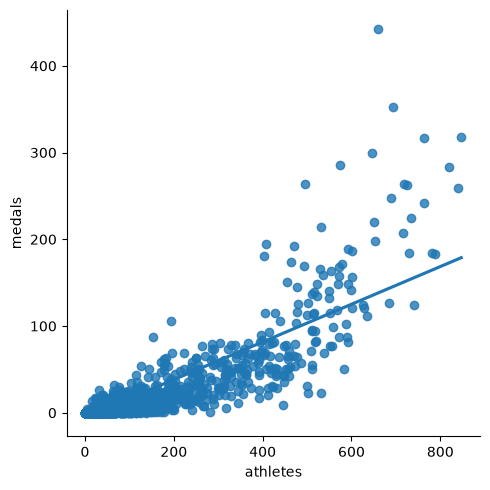

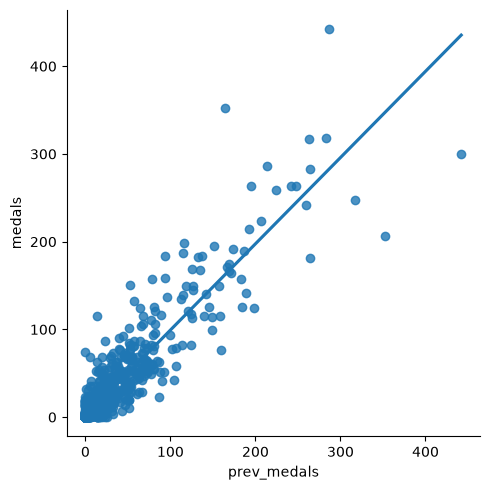

In [178]:
# scatter plot with a best fit line
sns.lmplot(x="athletes", y="medals", data=teams, fit_reg=True, ci=None)

sns.lmplot(x="prev_medals", y="medals", data=teams, fit_reg=True, ci=None)

Both plots trend upward, so a straight line (linear regression) fits. The points sit closer to the line for `prev_medals`, which makes it the stronger predictor.

<Axes: ylabel='Frequency'>

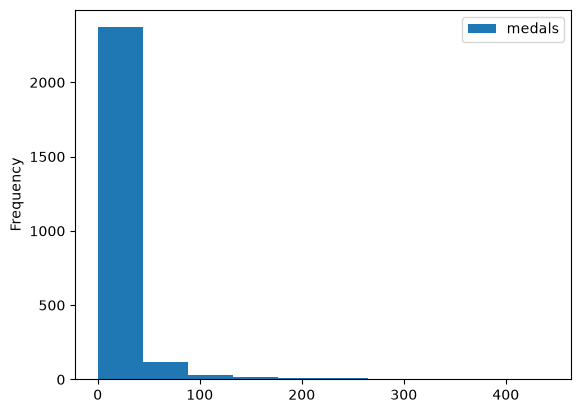

In [179]:
# how medal counts are spread out
teams.plot.hist(y="medals")

The data is **skewed**: most countries win 0 or a few medals, and only a handful win a lot. Expect larger errors for the big countries.

# Clean the data

The model can't handle missing values. Find them first, then remove them.

In [180]:
# count missing values in each column
display(teams.isnull().sum())

#show the rows that have a missing value
display(teams[teams.isnull().any(axis=1)])

# remove the rows with missing values
teams = teams.dropna()
teams.shape

team             0
country          0
year             0
athletes         0
prev_medals    131
medals           0
host             0
prev_host        0
dtype: int64

,team,country,year,athletes,prev_medals,medals,host,prev_host
21,AIN,AIN,2024,47,NaN,6,0,0
22,ALB,Albania,1992,9,NaN,0,0,0
31,ALG,Algeria,1964,7,NaN,0,0,0
46,AND,Andorra,1976,3,NaN,0,0,0
59,ANG,Angola,1980,17,NaN,0,0,0
...,...,...,...,...,...,...,...,...
2496,VIN,Saint Vincent and the Grenadines,1988,6,NaN,0,0,0
2509,YAR,North Yemen,1984,3,NaN,0,0,0
2511,YEM,Yemen,1992,8,NaN,0,0,0
2520,YMD,South Yemen,1988,5,NaN,0,0,0


(2425, 8)

The missing `prev_medals` values belong to each country's **first Olympics**, where there's no previous result to use. One is from 2024: the Individual Neutral Athletes (AIN), a new team that year.

# Error metric

**Mean Absolute Error (MAE)** is the average number of medals the predictions are off by. Lower is better.

# Split the data

Split by **year** so the model never learns from the future to predict the past.

- **Train:** 1964–2016
- **Test:** 2020 and 2024, the two most recent Olympics

In [181]:

# train up to 2016 the data the model learns from
train = teams[teams["year"] < 2020].copy()

# test 2020 and 2024 which the model has never seen
test = teams[teams["year"] >= 2020].copy()

train.shape, test.shape


((2014, 8), (411, 8))

# Train the model

Linear regression learns a formula: `medals = a × athletes + b × prev_medals + c`

In [182]:
# create an empty model
reg = LinearRegression()

predictors = ["athletes", "prev_medals", "host", "prev_host"]
target = "medals"

# learn from the training data
reg.fit(train[predictors], train[target])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.06, 0.78, 40.89,-23.26]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['athletes','prev_medals','host','prev_host']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.422
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [183]:
# predict medals for each row in test and save them in a new column
test["predictions"] = reg.predict(test[predictors])

#negative medals aren't possible so set those to 0
test.loc[test["predictions"] < 0, "predictions"] = 0

# round to whole medals
test["predictions"] = test["predictions"].round()

In [184]:
pd.Series(reg.coef_, index=predictors)

athletes        0.055474
prev_medals     0.784859
host           40.889774
prev_host     -23.259892
dtype: float64

# Results

In [185]:
# predict some countries at the 2024 Olympics
countries = ["USA", "CHN", "GBR", "FRA", "JPN", "AUS", "IND", "JAM"]

test["error"] = (test["medals"] - test["predictions"]).abs()
results = test[(test["team"].isin(countries)) & (test["year"] == 2024)]

display(results[["country", "medals", "predictions", "error"]])

mae = mean_absolute_error(test["medals"], test["predictions"])
print(f"MAE: {mae:.1f} medals off on average")

,country,medals,predictions,error
139,Australia,121,128.0,7.0
483,China,168,136.0,32.0
810,France,184,190.0,6.0
860,Great Britain,149,126.0,23.0
1080,India,22,24.0,2.0
1216,Jamaica,6,17.0,11.0
1243,Japan,82,105.0,23.0
2450,United States,318,268.0,50.0


MAE: 3.4 medals off on average


On average, the model is off by about **3.4 medals** on Olympics it had never seen.

**Adding host columns fixed the biggest misses:**
- **France 2024** (host): predicted 190, actual 184. Without host columns, it predicted 154.
- **Japan 2020** (host): predicted 131, actual 124. Before, it predicted 98.
- **Japan 2024** (just after hosting): predicted 105, actual 82. Before, it predicted 131.

The model learned that hosting adds about **41 medals** and that countries drop about **23** at the next Olympics.

Without the host columns, the MAE was 3.5. With them, it's 3.4.